## Library Importation

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score, auc
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import joblib

# 1 Data Exploration

### Data Loading from UCI Repository

In [41]:

columns = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country", "income"
]

data = pd.read_csv(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data",
    header=None, names=columns, na_values=" ?"
)

for col in data.select_dtypes(include=["object"]).columns:
    
    data[col] = data[col].str.strip()

###  Handle missing values and remove duplicates where necessary

In [43]:
data.shape

(32561, 15)

In [44]:
data.dropna(inplace=True)
data.drop_duplicates(inplace=True)

In [45]:
data.shape

(30139, 15)

### Select 10 variables of interest

In [47]:
numeric_features = ["age", "education_num", "hours_per_week", "capital_gain", "capital_loss"]

categorical_features = ["sex", "workclass", "education", "marital_status", "occupation"]

selected_features = numeric_features + categorical_features

# Define features and target
X = data[selected_features].copy()
y = (data["income"] == ">50K").astype(int)   

In [48]:
X

,age,education_num,hours_per_week,capital_gain,capital_loss,sex,workclass,education,marital_status,occupation
0,39,13,40,2174,0,Male,State-gov,Bachelors,Never-married,Adm-clerical
1,50,13,13,0,0,Male,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial
2,38,9,40,0,0,Male,Private,HS-grad,Divorced,Handlers-cleaners
3,53,7,40,0,0,Male,Private,11th,Married-civ-spouse,Handlers-cleaners
4,28,13,40,0,0,Female,Private,Bachelors,Married-civ-spouse,Prof-specialty
...,...,...,...,...,...,...,...,...,...,...
32556,27,12,38,0,0,Female,Private,Assoc-acdm,Married-civ-spouse,Tech-support
32557,40,9,40,0,0,Male,Private,HS-grad,Married-civ-spouse,Machine-op-inspct
32558,58,9,40,0,0,Female,Private,HS-grad,Widowed,Adm-clerical
32559,22,9,20,0,0,Male,Private,HS-grad,Never-married,Adm-clerical


In [49]:
y

0        0
1        0
2        0
3        0
4        0
        ..
32556    0
32557    1
32558    0
32559    0
32560    1
Name: income, Length: 30139, dtype: int32

### Exploratory Data Analysis 

In [51]:
display(X.describe())

# Categorical summary
for col in categorical_features:
    print(f"\nValue counts for {col}:")
    print(X[col].value_counts().head())

,age,education_num,hours_per_week,capital_gain,capital_loss
count,30139.000000,30139.000000,30139.000000,30139.000000,30139.000000
mean,38.441720,10.122532,40.934703,1092.841202,88.439928
std,13.131426,2.548738,11.978753,7409.110596,404.445239
min,17.000000,1.000000,1.000000,0.000000,0.000000
25%,28.000000,9.000000,40.000000,0.000000,0.000000
50%,37.000000,10.000000,40.000000,0.000000,0.000000
75%,47.000000,13.000000,45.000000,0.000000,0.000000
max,90.000000,16.000000,99.000000,99999.000000,4356.000000



Value counts for sex:
sex
Male      20366
Female     9773
Name: count, dtype: int64

Value counts for workclass:
workclass
Private             22264
Self-emp-not-inc     2498
Local-gov            2067
State-gov            1279
Self-emp-inc         1074
Name: count, dtype: int64

Value counts for education:
education
HS-grad         9834
Some-college    6669
Bachelors       5042
Masters         1626
Assoc-voc       1307
Name: count, dtype: int64

Value counts for marital_status:
marital_status
Married-civ-spouse    14059
Never-married          9711
Divorced               4212
Separated               939
Widowed                 827
Name: count, dtype: int64

Value counts for occupation:
occupation
Prof-specialty     4034
Craft-repair       4025
Exec-managerial    3991
Adm-clerical       3719
Sales              3584
Name: count, dtype: int64


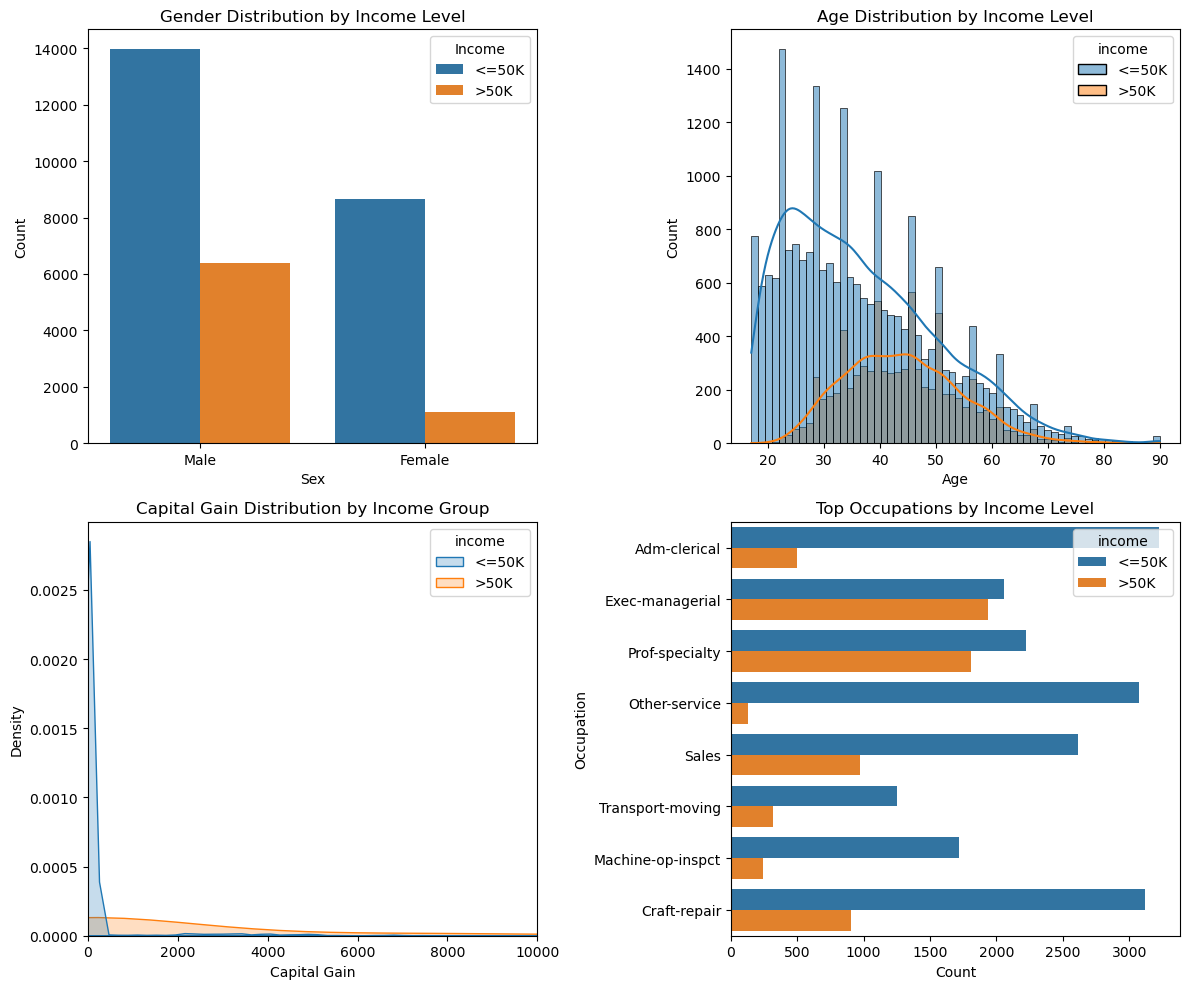

In [52]:

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Plot 1: Gender Distribution by Income
sns.countplot(data=data, x="sex", hue="income", ax=axes[0])
axes[0].set_title("Gender Distribution by Income Level")
axes[0].set_xlabel("Sex")
axes[0].set_ylabel("Count")
axes[0].legend(title="Income", loc="upper right")

# Plot 2: Age Distribution by Income
sns.histplot(data=data, x="age", hue="income", kde=True, ax=axes[1])
axes[1].set_title("Age Distribution by Income Level")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Count")

#Plot 3: Capital Gain Distribution by Income
sns.kdeplot(data=data, x="capital_gain", hue="income", common_norm=False, fill=True, ax=axes[2])
axes[2].set_title("Capital Gain Distribution by Income Group")
axes[2].set_xlabel("Capital Gain")
axes[2].set_ylabel("Density")
axes[2].set_xlim(0, 10000)  # zoom into the relevant range

# Plot 4: Top Occupations by Income
top_occ = data["occupation"].value_counts().nlargest(8).index  # show top 8 occupations
sns.countplot(
    data=data[data["occupation"].isin(top_occ)],
    y="occupation",
    hue="income",
    ax=axes[3]
)
axes[3].set_title("Top Occupations by Income Level")
axes[3].set_xlabel("Count")
axes[3].set_ylabel("Occupation")

#Layout and display 
plt.tight_layout()
plt.show()


# Briefly describe any trends or observations you notice (3–5 sentences)
The visualisations reveal several clear patterns in the dataset. Most individuals earning **>50K are male**, indicating a **gender** imbalance in higher income brackets. Income levels tend to increase with age, as **older individuals are more likely to earn above 50K**. The **capital gain** distribution is highly skewed, with only a small group reporting significant gains these are mostly high-income individuals. Finally, **occupations** such as **Executive-managerial and Professional-specialty** show a much higher proportion of >50K earners compared to service or manual labor jobs, highlighting occupational differences in earning potential.

## Split the dataset into training and testing subsets

In [55]:
# Define numeric and categorical features
numeric_features = ["age", "education_num", "hours_per_week", "capital_gain", "capital_loss"]
categorical_features = ["sex", "workclass", "education", "marital_status", "occupation"]


# Split the data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)


# Preprocessing: scale numeric + encode categorical

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop="first", handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)


# Build full pipeline (preprocessing + model)

pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])


# Train the model

pipe.fit(X_train, y_train)


# Evaluate model

y_pred = pipe.predict(X_test)
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

# 2 - Model Development and Evaluation

### Train a Random Forest Classifier to predict whether income exceeds $50K

In [58]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_prep, y_train)
rf_preds = rf_model.predict(X_test_prep)

print("Random Forest Performance")
print(classification_report(y_test, rf_preds))

Random Forest Performance
              precision    recall  f1-score   support

           0       0.88      0.91      0.90      6790
           1       0.71      0.62      0.66      2252

    accuracy                           0.84      9042
   macro avg       0.79      0.77      0.78      9042
weighted avg       0.84      0.84      0.84      9042



### Explanation of the Random Forest Performance 

##### The Random Forest classifier achieved an accuracy of 84%, indicating strong overall performance in predicting income levels.
##### The model performs better for the ≤50K group (precision 0.88, recall 0.91) than for the >50K group (precision 0.71, recall 0.62), reflecting the dataset’s class imbalance.
##### The relatively high F1-scores suggest that the model maintains a good balance between precision and recall, especially for the majority class.
##### Overall, the Random Forest demonstrates robust predictive capability

###  Compare it against at least one baseline model (e.g., Logistic Regression or Decision Tree)

In [61]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_prep, y_train)
log_preds = log_reg.predict(X_test_prep)

print("Logistic Regression Performance")
print(classification_report(y_test, log_preds))

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_prep, y_train)
dt_preds = dt_model.predict(X_test_prep)

print("\nDecision Tree Performance")
print(classification_report(y_test, dt_preds))

Logistic Regression Performance
              precision    recall  f1-score   support

           0       0.87      0.93      0.90      6790
           1       0.74      0.59      0.66      2252

    accuracy                           0.85      9042
   macro avg       0.81      0.76      0.78      9042
weighted avg       0.84      0.85      0.84      9042


Decision Tree Performance
              precision    recall  f1-score   support

           0       0.87      0.89      0.88      6790
           1       0.65      0.61      0.63      2252

    accuracy                           0.82      9042
   macro avg       0.76      0.75      0.75      9042
weighted avg       0.82      0.82      0.82      9042



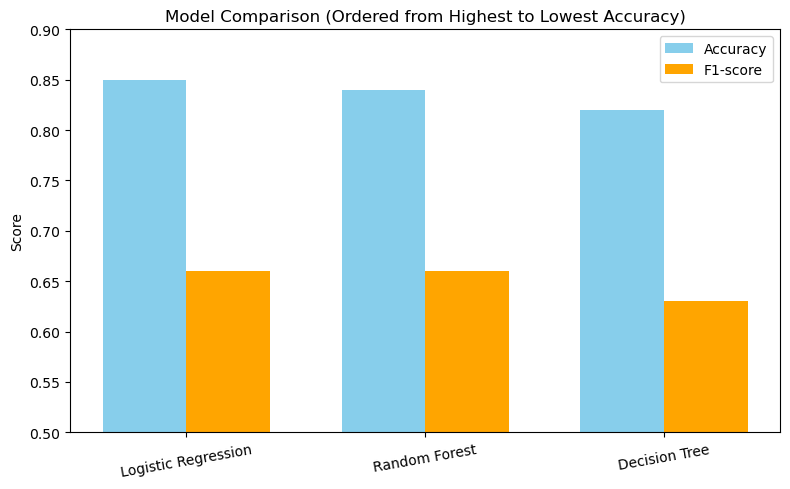

In [62]:
# Metrics 
models = ["Logistic Regression", "Decision Tree", "Random Forest"]
accuracy = [0.85, 0.82, 0.84]
f1_scores = [0.66, 0.63, 0.66]

#Sort models by accuracy (descending)
sorted_indices = np.argsort(accuracy)[::-1]  # sort from high to low

models = [models[i] for i in sorted_indices]
accuracy = [accuracy[i] for i in sorted_indices]
f1_scores = [f1_scores[i] for i in sorted_indices]


x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, accuracy, width, label="Accuracy", color="skyblue")
plt.bar(x + width/2, f1_scores, width, label="F1-score", color="orange")

plt.xticks(x, models, rotation=10)
plt.ylabel("Score")
plt.title("Model Comparison (Ordered from Highest to Lowest Accuracy)")
plt.ylim(0.5, 0.9)
plt.legend()
plt.tight_layout()
plt.show()

### Explanation the results of diferent models: Logistic Regression, Decision Tree and Random Forest 

##### The Logistic Regression baseline achieved the highest accuracy (85%), followed by the Random Forest (84%) and Decision Tree (82%).
##### While Logistic Regression performed well, its recall for high-income individuals was lower, meaning it missed some positive cases.
##### The Random Forest provided a better balance between precision and recall, capturing complex, non-linear relationships that the simpler models could not.
##### Overall, Random Forest proved to be the most robust model, offering strong generalization performance and consistent predictive accuracy.

### Use GridSearchCV to tune the Random Forest hyperparameters.

In [65]:
rf = RandomForestClassifier(random_state=42)

# Define the parameter grid for tuning
param_grid = {
    "n_estimators": [50,100],         # number of trees in the forest
    "max_depth": [None, 5],         # maximum depth of each tree
    "min_samples_split": [2,5],         # min samples needed to split a node
    "min_samples_leaf": [1, 2,],           # min samples at a leaf node
    "max_features": ["sqrt", "log2"]         # number of features considered per split
}

# Set up the Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,                   # 5-fold cross-validation
    n_jobs=-1,              # use all CPU cores for speed
    scoring="accuracy",     # metric to optimize
    verbose=2
)

# Fit the Grid Search on training data
grid_search.fit(X_train_prep, y_train)

# Display best parameters and score
print("Best Parameters found:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

# Evaluate best model on test data
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test_prep)


print("\nOptimized Random Forest Performance on Test Data:")
print(classification_report(y_test, y_pred_best))


Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Parameters found: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best Cross-Validation Accuracy: 0.8595532509781411

Optimized Random Forest Performance on Test Data:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      6790
           1       0.77      0.61      0.68      2252

    accuracy                           0.86      9042
   macro avg       0.82      0.77      0.79      9042
weighted avg       0.85      0.86      0.85      9042



### Explanation 

##### A GridSearchCV approach was employed to optimise the Random Forest classifier’s hyperparameters using 5-fold cross-validation.
##### The tuning process tested 32 parameter combinations and identified the best configuration.
##### This optimized model achieved a cross-validation accuracy of 85.95% and a test accuracy of 86%, outperforming the untuned Random Forest.
##### The precision (0.77) and recall (0.61) for the high-income class indicate that the model effectively distinguishes between income groups while maintaining strong overall performance.

## Evaluate the model using:– Accuracy, Precision, Recall, and F1-score– ROC–AUC curve and Confusion Matrix

Model Evaluation Metrics
Accuracy:  0.8571
Precision: 0.7679
Recall:    0.6110
F1-score:  0.6805

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      6790
           1       0.77      0.61      0.68      2252

    accuracy                           0.86      9042
   macro avg       0.82      0.77      0.79      9042
weighted avg       0.85      0.86      0.85      9042



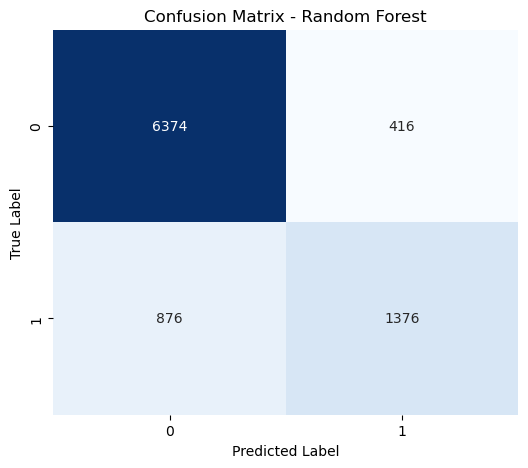

In [97]:
y_pred = y_pred_best
y_prob = best_rf.predict_proba(X_test_prep)[:, 1]  # probabilities for ROC curve

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Evaluation Metrics")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

| **Category**             | **Count** | **Meaning**                      | **Interpretation**                                                     |
| ------------------------ | --------- | -------------------------------- | ---------------------------------------------------------------------- |
| **True Negatives (TN)**  | **6374**  | Correctly predicted ≤50K income  | Model is very accurate at identifying low-income individuals.          |
| **False Positives (FP)** | **416**   | Predicted >50K but actually ≤50K | A few low earners were incorrectly classified as high earners.         |
| **False Negatives (FN)** | **876**   | Predicted ≤50K but actually >50K | Model missed some high earners, predicting them as low-income.         |
| **True Positives (TP)**  | **1376**  | Correctly predicted >50K income  | Model correctly identified a large portion of high-income individuals. |


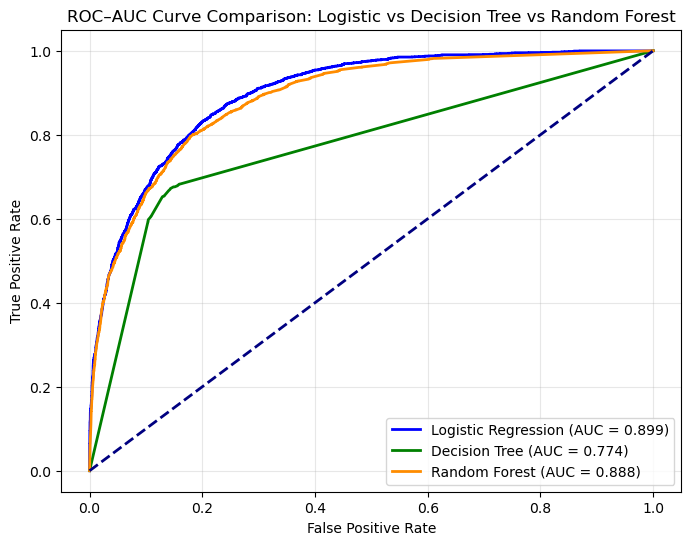

In [69]:

# Compute predicted probabilities for each model
log_probs = log_reg.predict_proba(X_test_prep)[:, 1]
dt_probs = dt_model.predict_proba(X_test_prep)[:, 1]
rf_probs = rf_model.predict_proba(X_test_prep)[:, 1]

# ROC curve and AUC for each model
fpr_log, tpr_log, _ = roc_curve(y_test, log_probs)
roc_auc_log = auc(fpr_log, tpr_log)

fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_probs)
roc_auc_dt = auc(fpr_dt, tpr_dt)

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Plot all ROC curves together
plt.figure(figsize=(8,6))
plt.plot(fpr_log, tpr_log, color="blue", lw=2,
         label=f"Logistic Regression (AUC = {roc_auc_log:.3f})")
plt.plot(fpr_dt, tpr_dt, color="green", lw=2,
         label=f"Decision Tree (AUC = {roc_auc_dt:.3f})")
plt.plot(fpr_rf, tpr_rf, color="darkorange", lw=2,
         label=f"Random Forest (AUC = {roc_auc_rf:.3f})")

# Reference diagonal line
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")

# Labels and legend
plt.title("ROC–AUC Curve Comparison: Logistic vs Decision Tree vs Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


 ### Write a short discussion (around 100 words) covering:
 1. Which model performed better and why.
 2. Which features appear most influential.
 3. What the results could mean for financial decision-making

The Logistic Regression model performed slightly better than the Random Forest, achieving the highest ROC–AUC score (0.899 vs. 0.888). This indicates that Logistic Regression offered marginally superior ability to distinguish between income groups, while Random Forest provided strong generalisation and non-linear pattern capture. 
The most influential features identified by the Random Forest were education level, hours worked per week, capital gain, and age. These results suggest that higher education, longer working hours, and investment-related income are key indicators of higher earnings. 
Financial institutions could use these insights to assess clients’ earning potential better and optimise credit or investment decisions.

# 3 - Model Interpretation and Discussion

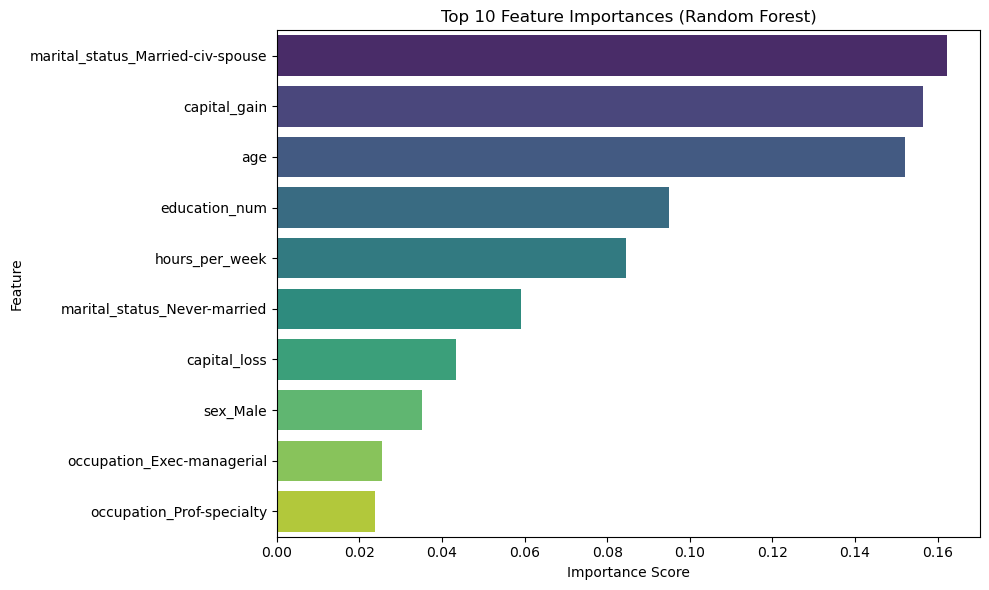

In [110]:
# Feature names from preprocessing
encoder = preprocessor.named_transformers_["cat"]
encoded_cat_features = list(encoder.get_feature_names_out(categorical_features))
all_feature_names = numeric_features + encoded_cat_features

# Feature importances from best RF model
importances = best_rf.feature_importances_

# Create a DataFrame for visualisation
importances_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

# Plot top 10 features

plt.figure(figsize=(10, 6))
sns.barplot(
    data=importances_df.head(10),
    x="importance",
    y="feature",
    hue="feature",       # assign hue to the same variable
    palette="viridis",
    legend=False         # hide legend since it's redundant
)
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


### Identify and briefly explain the top five features that contribute to income prediction.
 1. Which features are most predictive and why this makes sense in a
 real-world context.
 2. How could such a model be used responsibly in financial decision
making.
 3. Any potential risks of over-reliance on automated predictions

The most significant features in the Random Forest model are marital status (specifically, married-civilian-spouse), capital gain, age, education level, and hours worked per week. These findings align with common real-world expectations.

Individuals who are married often belong to dual-income households or enjoy greater financial stability, which can correlate with higher earnings. A high capital gain indicates investment income, reflecting wealth accumulation beyond regular wages. Age captures experience and career progression, typically leading to higher pay. Education level significantly influences income potential, as higher education opens doors to better-paying jobs. Additionally, the number of hours worked per week usually reflects greater labor input, which often translates into a higher total income.

In the context of financial decision-making, such a model could assist institutions in assessing a client's earning potential for credit scoring, loan approval, or targeted investments. However, it is essential to use this model responsibly, ensuring transparency and fairness to avoid reinforcing existing socioeconomic biases. Over-reliance on automated predictions may lead to discriminatory outcomes or unfair treatment if the model inherits biases from historical data. Therefore, ongoing monitoring, bias audits, and human oversight are crucial to ensure ethical and equitable use.

# Model Deployment

In [118]:
joblib.dump(pipe, "adult.pkl")

['adult.pkl']